# Homework 1 — The ML Framework

This is your first homework; it follows **Session 02: The ML Framework**.
You'll go from a short PyTorch warm-up to **building logistic regression from
scratch**, and finish with a **prediction contest**.

The lecture's recipe is the spine of this whole assignment:

> **model → loss → optimization → generalization**


> 📚 **Reading materials** (in the `reading/` folder — review these before starting):
> - **`Session_02_Summary.pdf`** — recap of Session 02 (the ML framework: model → loss → optimization → generalization). Your quickest refresher for this homework.
> - **`220-logistic-regression.pdf`** — a deeper reference on logistic regression (the model, cross-entropy loss, and gradient descent) that Part 2 asks you to build.

> ### 🚫 Do not use AI to write the code in this homework
> Don't use AI assistants (ChatGPT, Copilot, Claude, etc.) to write your answers.
> Doing so defeats the purpose: the goal is for **you** to learn these essentials.
> You need to fundamentally understand how these pieces work so that, later, you can
> leverage AI for code far more effectively — knowing what to ask for, and being able
> to tell when its output is right or wrong. Using AI to look up a concept or debug
> your *understanding* is fine; using it to produce the code you're asked to write is not.


| Part | Topic | What you do |
|------|-------|-------------|
| **Part 1** | PyTorch basics *(read-only)* | A tour of tensors, vectorization, and autograd. Nothing to hand in. |
| **Part 2** | Logistic regression from scratch | Implement `sigmoid`, `bce_loss`, the model, and gradient descent, then run a **learning-rate ablation**. |
| **Part 3** | Contest | Train your best model and produce a `submission.csv` we will score. |

**We assume you can already program.** This course does not teach programming
from scratch. If you're new to **Python** specifically, work through Google's
free [Python tutorial](https://developers.google.com/edu/python) first, then come
back — the rest of this notebook assumes you're comfortable with Python.

**How to work:** look for cells marked `# TODO`. Replace the
`raise NotImplementedError(...)` line with your code. After each piece, run the
matching self-check cell — it prints `PASS` / `FAIL`.

> 📊 **Dataset:** the [MAGIC Gamma Telescope](https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope)
> set — 19,020 telescope events, 10 numeric features, and a binary label
> (*gamma* signal vs *hadron* background). `load_data` reads it (it's included
> in `data/`), then standardizes and splits it for you.

---
## Getting started (read this first if you're new to notebooks)

**What is this file?** A *Jupyter notebook* (`.ipynb`). It's split into **cells**.
A cell is either **text** (like this one) or **code** you can run. You run a cell by
clicking it and pressing **Shift + Enter**. Output appears right below the cell. You
work **top to bottom** — run cells in order, because later cells use things defined
earlier.

### 1. Install Python
If you don't have Python yet, the easiest path for beginners is **Anaconda**, which
bundles Python, Jupyter, and most packages: <https://www.anaconda.com/download>.
(Advanced users can use plain Python from <https://www.python.org/downloads/>.)
This homework needs **Python 3.9 or newer**.

### 2. Open this notebook
Pick whichever is easiest:

- **VS Code** — install the *Python* and *Jupyter* extensions, then open
  `homework1.ipynb`. Recommended.
- **Jupyter in your browser** — open a terminal (Anaconda Prompt on Windows) in
  this `hw1` folder and run `jupyter notebook`, then click `homework1.ipynb`.
- **Google Colab** — go to <https://colab.research.google.com>, upload the notebook
  *and* the `hw1_*.py` helper files (Colab already has the packages installed).

### 3. Install the required packages
We use a few standard libraries: `numpy`, `pandas`, `matplotlib`, `scikit-learn`,
and `torch` (PyTorch). You only need to do this **once** per computer.

The simplest way is to run the **next code cell** (it installs them from inside the
notebook). Prefer a terminal? From this folder run instead:

```bash
pip install -r requirements.txt
```

> If `pip` isn't found, try `pip3`. On Anaconda you can also use
> `conda install numpy pandas matplotlib scikit-learn` and install PyTorch per the
> instructions at <https://pytorch.org/get-started/locally/>. You do **not** need a
> GPU — everything here runs on CPU in seconds.

**Run this cell once to install the packages.** It's safe to re-run; if things
are already installed it just confirms. Restart the kernel afterward if asked
(menu: *Kernel → Restart*).

In [ ]:
# Installs the homework's packages. Safe to re-run.
import sys, subprocess
pkgs = ["numpy", "pandas", "matplotlib", "scikit-learn", "torch"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs])
print("Done. If you saw errors about 'torch', see https://pytorch.org/get-started/locally/")

### 4. Check everything works
Run the next cell. If it prints the versions with no red errors, you're ready —
start with **Part 0** below. If a package is "not found", re-run the install cell
above, then restart the kernel (*Kernel → Restart*) and try again.

In [11]:
# Quick environment check
import importlib
for name in ["numpy", "pandas", "matplotlib", "sklearn", "torch"]:
    try:
        m = importlib.import_module(name)
        print(f"OK  {name:12s} {getattr(m, '__version__', '')}")
    except ImportError:
        print(f"MISSING  {name}  <- run the install cell above")

OK  numpy        2.4.6
OK  pandas       3.0.3
OK  matplotlib   3.11.0
OK  sklearn      1.9.0
OK  torch        2.12.0+cpu


## Part 0 — Setup
Run this first. It imports everything and fixes the random seed so your results are reproducible.

In [12]:
import numpy as np
import torch


torch.manual_seed(0)
np.random.seed(0)

print("torch", torch.__version__)
print("Setup OK")

torch 2.12.0+cpu
Setup OK


### Provided helpers
The data loader and plotting helpers live in **`hw1_tests.py`** (the single support
file for this homework). Run the next cell to import them — you don't need to read
or edit them. They load the MAGIC dataset that's included in `data/`.

In [13]:
# Data + plotting helpers (defined in hw1_tests.py):
from hw1_tests import load_data, plot_loss_curve
print("Helpers imported from hw1_tests.py")

Helpers imported from hw1_tests.py


---
# Part 1 — PyTorch basics (informative)

You already know how to program, but you may be new to **PyTorch**, the library we
use for the rest of the course. **This part is just a tour — there's nothing to
hand in here.** Read the notes and *run each demo cell* to see the output. Once you
reach Part 2, you'll put these ideas to work (and that's where the graded code and
self-checks begin).

**What is PyTorch, compared to plain Python?** Python lists are fine for general
code but slow for the heavy array math ML needs. PyTorch gives you the **tensor**:
an n-dimensional array that runs **vectorized** math in fast compiled code (no
element loops), **broadcasts** shapes like NumPy, can run on a **GPU**, and — the
key feature — computes **gradients automatically** (*autograd*).

We cover only what logistic regression needs: tensors, element-wise math,
reductions, matrix multiplication, and autograd. **No neural networks here.** For a
fuller, hands-on tour see this
[Intro to PyTorch notebook](https://colab.research.google.com/drive/1Mp-TRzw-ftz15PAe7iWiOn46H8I39aW-#scrollTo=ILv_ULvszzhE).

### 1.1 — Tensors & indexing
A tensor is an n-dimensional array. You make one from a list (or NumPy array), check
its `.shape`/`.dtype`, and pull out parts with indexing/slicing — `t[i]`, `M[i, j]`,
`M[:, j]` (a whole column).

In [14]:
import torch

v = torch.tensor([10.0, 20.0, 30.0])                  # 1-D
M = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])  # 2-D, shape (2, 3)

print("v shape:", tuple(v.shape), "| dtype:", v.dtype)
print("M shape:", tuple(M.shape))
print("v[0]    =", v[0].item())     # first element
print("M[0]    =", M[0])            # first ROW
print("M[1, 2] =", M[1, 2].item())  # row 1, col 2 -> 6.0
print("M[:, 0] =", M[:, 0])         # first COLUMN
print("zeros (2,2):\n", torch.zeros((2, 2)))

v shape: (3,) | dtype: torch.float32
M shape: (2, 3)
v[0]    = 10.0
M[0]    = tensor([1., 2., 3.])
M[1, 2] = 6.0
M[:, 0] = tensor([1., 4.])
zeros (2,2):
 tensor([[0., 0.],
        [0., 0.]])


### 1.2 — Element-wise math (vectorization)
Operators (`+ - * /`, `**`) and functions (`torch.exp`, `torch.log`) act on **every
element at once** — no loop. Scalars **broadcast** to the whole tensor. We'll use
`exp` and `log` when building the sigmoid and the cross-entropy loss.

In [15]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("a * b        =", a * b)        # element-wise multiply
print("a + 10       =", a + 10)       # scalar broadcasts everywhere
print("(a - b) ** 2 =", (a - b) ** 2) # element-wise squared difference
print("torch.exp(a) =", torch.exp(a))
print("torch.log(b) =", torch.log(b))

a * b        = tensor([ 4., 10., 18.])
a + 10       = tensor([11., 12., 13.])
(a - b) ** 2 = tensor([9., 9., 9.])
torch.exp(a) = tensor([ 2.7183,  7.3891, 20.0855])
torch.log(b) = tensor([1.3863, 1.6094, 1.7918])


### 1.3 — Reductions & boolean masks
A **reduction** collapses a tensor to fewer numbers — `.sum()`, `.mean()`. This is
what a *loss* does: many per-example errors → one number. A **comparison** gives a
boolean tensor; `.sum()` counts the `True`s and `.float().mean()` gives a rate —
which is how we'll compute **accuracy** in Part 2.

In [16]:
t = torch.tensor([1.0, 5.0, 2.0, 8.0])
print("sum  =", t.sum().item(), " mean =", t.mean().item())

mask = t > 3.0                                  # boolean tensor
print("mask            =", mask)
print("count > 3       =", mask.sum().item())          # how many
print("fraction > 3    =", mask.float().mean().item()) # what share

sum  = 16.0  mean = 4.0
mask            = tensor([False,  True, False,  True])
count > 3       = 2
fraction > 3    = 0.5


### 1.4 — Matrix multiplication & shapes
`@` is matrix multiply. An `(n, k)` times a `(k, m)` gives `(n, m)` — the inner
dimensions must match. Vectors and biases **broadcast** when added. In Part 2 the
model's score is exactly one matmul plus a bias: `X @ w + b`.

In [17]:
A = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])  # (2, 3)
B = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])  # (3, 2)
C = A @ B                                                # (2, 2)
print("A", tuple(A.shape), "@ B", tuple(B.shape), "-> C", tuple(C.shape))
print("C =\n", C)

# the model's linear score: features (N,D) @ weights (D,1) + bias -> (N,1)
X_demo = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
w_demo = torch.tensor([[1.0], [0.0]]); b_demo = torch.tensor([0.5])
print("X_demo @ w_demo + b_demo =\n", X_demo @ w_demo + b_demo)

A (2, 3) @ B (3, 2) -> C (2, 2)
C =
 tensor([[ 4.,  5.],
        [10., 11.]])
X_demo @ w_demo + b_demo =
 tensor([[1.5000],
        [3.5000]])


### 1.5 — Autograd: the feature plain Python can't match
Mark a tensor with `requires_grad=True` and PyTorch records every operation on it.
Call `.backward()` on the result and the derivative lands in `.grad`. This is how
Part 2 learns — you never hand-derive gradients.

In [18]:
x = torch.tensor(2.0, requires_grad=True)
f = x ** 2 + 3 * x          # f(x) = x^2 + 3x
f.backward()                # compute df/dx
print("f(2)      =", f.item())
print("df/dx at 2 =", x.grad.item(), " (analytic 2x + 3 = 7)")

f(2)      = 10.0
df/dx at 2 = 7.0  (analytic 2x + 3 = 7)


### 1.6 — Putting it together: one gradient-descent loop
This is the exact pattern Part 2's `train` function uses, so study it. To *minimize*
a loss we repeatedly: compute the loss, `backward()` for gradients, then nudge the
parameters **downhill** — inside `torch.no_grad()` so the update isn't recorded, and
we **zero the gradients** after each step (PyTorch accumulates them otherwise).
Below we minimize `f(w) = (w - 3)²`; `w` should march toward 3.

In [19]:
w = torch.tensor([0.0], requires_grad=True)
lr = 0.1
for step in range(40):
    loss = (w - 3.0) ** 2     # 1. forward: compute the loss
    loss.backward()           # 2. backward: fills w.grad
    with torch.no_grad():     # 3. update without recording it
        w -= lr * w.grad      #    step downhill: w <- w - lr * grad
        w.grad.zero_()        # 4. reset grad for the next step
    if step % 10 == 0:
        print(f"step {step:2d}  w = {w.item():.4f}  loss = {loss.item():.4f}")
print("final w (should be ~3):", round(w.item(), 4))

step  0  w = 0.6000  loss = 9.0000
step 10  w = 2.7423  loss = 0.1038
step 20  w = 2.9723  loss = 0.0012
step 30  w = 2.9970  loss = 0.0000
final w (should be ~3): 2.9996


That's the whole of optimization: forward → backward → step → zero. Everything in
Part 2 is this loop applied to the logistic-regression loss. ✅ You now know enough
PyTorch to build it — and Part 2 is where you start writing (and checking) code.

---
# Part 2 — Logistic regression from scratch (PyTorch)

This is the heart of the homework. You'll build every box of the lecture's recipe
yourself: the **model** (a `LinearClassifier`), the **loss** (binary cross-entropy),
and the **optimization** (gradient descent). Then you'll probe how the
learning rate matters through a short **ablation**.

> ### ⚠️ Build the math yourself — the one rule for Part 2
> **Use** `nn.Module` and `nn.Parameter` to structure the model the standard
> PyTorch way, plus basic tensor ops: `+ - * / @`, `torch.exp`, `torch.log`,
> `.sum()`, `.mean()`, comparisons, and autograd (`.backward()`, `.grad`,
> `torch.no_grad()`, `model.zero_grad()`).
> **Do NOT use** the high-level pieces that would do the actual work for you:
> `nn.Linear`, `torch.sigmoid`, `torch.nn.functional` (e.g. `binary_cross_entropy`),
> or `torch.optim`. The point is to see what those one-liners are really doing.

Run the cell below to load the data (the bundled MAGIC dataset).

In [20]:
data = load_data(seed=0)
X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]

print("features:", data["feature_names"])
print("classes :", data["classes"])
print("train/val/test:", X_train.shape, X_val.shape, X_test.shape)

features: ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']
classes : ['hadron', 'gamma']
train/val/test: torch.Size([13314, 10]) torch.Size([2853, 10]) torch.Size([2853, 10])


### 2.1 — The link: `sigmoid`
The linear score $w\cdot x + b$ is unbounded, but we need a probability in
$[0,1]$. The sigmoid squashes it:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Implement it element-wise and numerically stable for large inputs
(`sigmoid(torch.tensor(-100.))` must not error). Use `torch.exp` — **not**
`torch.sigmoid`.

In [21]:
def sigmoid(z: torch.Tensor) -> torch.Tensor:
    """Element-wise logistic sigmoid.

    Args:
        z: a tensor of ANY shape (the linear scores / logits).
    Returns:
        a tensor of the SAME shape as z, with every entry in (0, 1).
    """
    # TODO: element-wise 1 / (1 + e^{-z}); use torch.exp, NOT torch.sigmoid
    return 1.0 / (1.0 + torch.exp(-z))



In [22]:
from hw1_tests import check_sigmoid
check_sigmoid(sigmoid)

[PASS] sigmoid


True

### 2.2 — The model: `LinearClassifier(nn.Module)`
A PyTorch model subclasses **`nn.Module`** and defines a **`forward`** method;
calling the model (`model(X)`) runs `forward` for you.

The learnable tensors are stored as **`nn.Parameter`**. Wrapping a tensor with
`nn.Parameter(t)` does two things:
1. it sets `requires_grad=True`, so autograd tracks it, and
2. it **registers** the tensor on the module, so it automatically shows up in
   `model.parameters()` — which your `train` loop and `model.zero_grad()` depend on.

You create the parameters inside `__init__` (after calling `super().__init__()`),
give each one a name like `self.w`, and read them back in `forward` as `self.w`.

**Your task — a linear classifier** $f(x) = \sigma(Xw + b)$:
- In `__init__`: register two parameters — a **weight** that maps the `n_features`
  inputs to a single output, and a **scalar bias**. Initialize both to zeros.
- In `forward`: form the linear score from `X` and your parameters, pass it through
  **your** `sigmoid`, and return probabilities of shape `(N, 1)`.

Don't use `nn.Linear` — that's exactly the piece you're reimplementing.

In [24]:
import torch.nn as nn


class LinearClassifier(nn.Module):
    """Linear classifier f(x) = sigmoid(X @ w + b), built on nn.Module."""

    def __init__(self, n_features: int) -> None:
        """Args:
            n_features: number of input features D (each X has shape (N, D)).

        Create two learnable parameters (with nn.Parameter), both zero-initialized:
            self.w -> shape (n_features, 1)   the weights
            self.b -> shape (1,)              the bias
        """
        super().__init__()
        # TODO: register self.w and self.b as nn.Parameter with the shapes above.
        self.w = nn.Parameter(torch.zeros((n_features, 1)))
        self.b = nn.Parameter(torch.zeros((1,)))


    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """Args:
            X: (N, n_features) float tensor of features.
        Returns:
            (N, 1) tensor of probabilities in (0, 1).
        """
        # TODO: linear score from X and your parameters, through your sigmoid.
        return sigmoid(X @ self.w + self.b)


In [25]:
from hw1_tests import check_model
check_model(LinearClassifier)

[PASS] LinearClassifier


True

### 2.3 — The loss: binary cross-entropy
Derived from maximum likelihood in lecture. For predicted probabilities
$\hat y$ and labels $y \in \{0,1\}$:

$$\text{BCE} = -\frac{1}{N}\sum_i \big[ y_i \log \hat y_i + (1 - y_i)\log(1 - \hat y_i) \big]$$

Return the **mean** loss (a scalar tensor). Clamp `y_pred` to `[1e-7, 1-1e-7]` to
avoid `log(0)`. Build it from `torch.log` and tensor ops — **not**
`torch.nn.functional.binary_cross_entropy`.

In [29]:
def bce_loss(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    """Mean binary cross-entropy.

    Args:
        y_pred: (N, 1) predicted probabilities, each in (0, 1).
        y_true: (N, 1) true labels, each exactly 0.0 or 1.0.
    Returns:
        a scalar tensor (0-dim): the mean BCE over the N examples.
    """
    # TODO: clamp y_pred to [1e-7, 1-1e-7], then return the mean BCE.

    y_pred = torch.clamp(y_pred, 1e-7, 1.0 - 1e-7)
    return -(y_true * torch.log(y_pred) + (1.0 - y_true) * torch.log(1.0 - y_pred)).mean()


In [30]:
from hw1_tests import check_bce_loss
check_bce_loss(bce_loss)

[PASS] bce_loss


True

### 2.4 — The metric: `accuracy`
Threshold the probabilities at 0.5 and return the fraction correct (a scalar).

In [31]:
def accuracy(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    """Classification accuracy at a 0.5 threshold.

    Args:
        y_pred: (N, 1) predicted probabilities, each in (0, 1).
        y_true: (N, 1) true labels, each 0.0 or 1.0.
    Returns:
        a scalar tensor: the fraction of correct predictions, in [0, 1].
    """
    # TODO: threshold probabilities at 0.5 and return the fraction correct.
    hard_predictions = (y_pred >= 0.5).float()
    correct = (hard_predictions == y_true)
    return correct.float().mean()


In [32]:
from hw1_tests import check_accuracy
check_accuracy(accuracy)

[PASS] accuracy


True

### 2.5 — Evaluating the model
A small convenience that bundles your metrics. Given a trained model and a dataset,
report both the **loss** and the **accuracy**. Wrap the computation in
`torch.no_grad()` (no gradients are needed at evaluation time — it's faster and uses
less memory) and return a dict `{"loss": float, "accuracy": float}`. You'll reuse
this on the validation and test sets and throughout the ablations.

In [33]:
def evaluate(model: nn.Module, X: torch.Tensor, y: torch.Tensor) -> dict[str, float]:
    """Evaluate a trained model on a dataset (no gradient tracking).

    Args:
        model: a LinearClassifier, mapping (N, D) features -> (N, 1) probabilities.
        X: (N, D) features.
        y: (N, 1) true labels, each 0.0 or 1.0.
    Returns:
        {"loss": float, "accuracy": float} computed on (X, y).
    """
    # TODO: under torch.no_grad(), get the model's probabilities and return the dict.
    with torch.no_grad():
        y_pred = model(X)
        loss_val = bce_loss(y_pred, y).item()
        acc_val = accuracy(y_pred, y).item()

    return {"loss": loss_val, "accuracy": acc_val}


In [34]:
from hw1_tests import check_evaluate
check_evaluate(evaluate)

[PASS] evaluate


True

### 2.6 — Optimization: the training loop
Now train the model. **This is exactly the gradient-descent loop from Part 1.6** —
forward → `backward()` → step under `torch.no_grad()` → zero the gradients — applied
to the BCE loss. `train` updates the model's parameters **in place** and returns the
per-epoch loss history. Loop over `model.parameters()` so the same loop works for any
number of parameters.

In [35]:
def train(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    lr: float = 0.1,
    epochs: int = 300,
) -> list[float]:
    """Full-batch gradient descent. Trains `model` IN PLACE.

    Args:
        model: a LinearClassifier (its parameters are updated each step).
        X: (N, D) training features.
        y: (N, 1) training labels, each 0.0 or 1.0.
        lr: learning rate (step size).
        epochs: number of full passes over the data.
    Returns:
        history: a list of length `epochs`, the loss after each step.
    """
    history: list[float] = []
    for _ in range(epochs):
        # TODO (the loop from Part 1.6):
          p = model(X)
          loss = bce_loss(p, y)
          model.zero_grad()
          loss.backward()
          with torch.no_grad():
             for param in model.parameters():
                 param -= lr * param.grad
          history.append(loss.item())

    return history


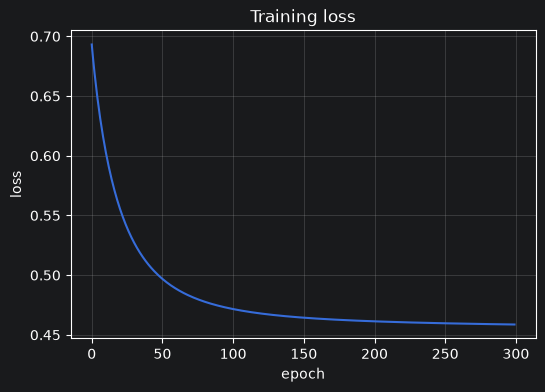

validation: {'loss': 0.4683418869972229, 'accuracy': 0.7844374179840088}
test:       {'loss': 0.4616466164588928, 'accuracy': 0.7858394384384155}


In [36]:
# After implementing everything above, train and inspect (uncomment):
model = LinearClassifier(n_features=X_train.shape[1])
history = train(model, X_train, y_train, lr=0.1, epochs=300)
plot_loss_curve(history, title="Training loss")
print("validation:", evaluate(model, X_val, y_val))
print("test:      ", evaluate(model, X_test, y_test))

### 2.7 — Ablation: the learning rate
The learning rate $\eta$ is the one knob to respect. Train the model with several
learning rates and plot the **training-loss curve** for each on the same axes. You
should see the lecture's three regimes:
- **too small** → the loss barely moves (training is painfully slow),
- **too big** → the loss bounces around or diverges,
- **just right** → a smooth, fast descent.

Run the cell, then write **1–3 sentences** on what you observe and why (tie it back
to the gradient-descent step `w ← w − η·∇L`).

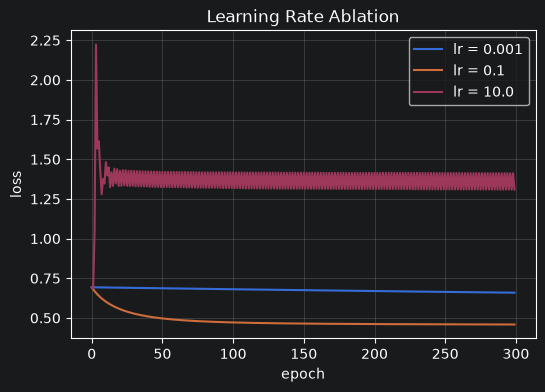

In [37]:
# TODO: train the model at several learning rates, collect each run's loss
# history, and overlay them on one plot to compare.
# Hint: plot_loss_curve accepts a dict {label: loss_history} and overlays the curves.


learning_rates = [0.001, 0.1, 10.0]
histories = {}

for lr in learning_rates:

    model = LinearClassifier(n_features=X_train.shape[1])


    history = train(model, X_train, y_train, lr=lr, epochs=300)


    histories[f"lr = {lr}"] = history


plot_loss_curve(histories, title="Learning Rate Ablation")



When the learning rate is too small (lr=0.001), the model learns very slowly because the steps it takes (η·∇L) are tiny. When the learning rate is too big (lr=10.0), the steps are too large, so the model jumps over the correct answer and the error goes up and down randomly. But when the learning rate is just right (lr=0.1), the model learns fast and smoothly finds the best answer without jumping around.

### 2.8 — Run all self-checks
Run this once your model and functions are implemented. Passing all checks means the
**building blocks** are correct — it does **not** guarantee a top contest score.

In [38]:
from hw1_tests import run_all
run_all(globals())

Running Homework 1 self-checks (Part 2 building blocks)...

[PASS] sigmoid
[PASS] LinearClassifier
[PASS] bce_loss
[PASS] accuracy
[PASS] evaluate

5/5 checks passed


True

---
# Part 3 — Contest

Put your skills to the test on a held-out dataset. **You may use any model and any
library** — your Part 2 `LinearClassifier`, scikit-learn, anything. You're graded on
predictions, not implementation.

The data is in `data/`:
- **`contest_train.csv`** — labeled training data: a `label` column (1 = purchase)
  plus the feature columns.
- **`contest_test.csv`** — the test set: an `example_id` column plus the same
  features, **with the labels hidden**.

The features are **anonymized** (`f01`, `f02`, …) except `Month` — part of the
challenge is working out which columns carry signal and which are useless. And
**validate carefully**: the test set may differ from the training set in ways that
punish a model that simply overfits the training data.

Your job: train a model and, for every `example_id`, output both a 0/1 `prediction`
and a `probability` = P(label = 1). Save them to `contest/submission.csv` with columns
**`example_id,prediction,probability`**, then validate it.

### 1. Load the training data

In [39]:
import pandas as pd

train_df = pd.read_csv("data/contest_train.csv")
y_train_c = train_df["label"]
X_train_c = train_df.drop(columns=["label"])
print("training data:", X_train_c.shape)
train_df.head()

training data: (8606, 22)


,f10,f02,f07,f18,f15,f21,Month,f12,f06,f04,...,f16,f09,f17,f14,f03,f08,f11,f01,f13,label
0,0,0.000000,-0.7902,-0.1274,-0.0814,2,Nov,6,1.2349,3,...,3913.987030,190.416667,0.0191,78,1,5,0.005425,0.0,0.006561,0
1,1,0.000000,-1.0346,-0.6355,0.1085,2,Dec,0,0.3719,3,...,172.208333,0.000000,0.0457,6,2,6,0.033333,0.0,0.044444,1
2,0,0.000000,0.6033,0.3381,0.8768,2,Nov,1,0.7479,3,...,787.535714,8.000000,0.0101,27,20,1,0.000000,0.0,0.005143,0
3,1,23.033294,1.7443,0.3224,-0.3468,4,May,0,0.4394,2,...,782.083333,0.000000,0.0214,33,2,9,0.000000,35.0,0.005882,1
4,0,18.854458,0.6903,0.1754,-0.0928,2,Nov,0,0.3405,2,...,640.875000,0.000000,0.0071,10,2,1,0.000000,0.0,0.011111,1


### 2. Load the test set (labels hidden)

In [40]:
test_df = pd.read_csv("data/contest_test.csv")
X_test_c = test_df.drop(columns=["example_id"])
print("test data:", X_test_c.shape, "(labels hidden)")
test_df.head()

test data: (3724, 22) (labels hidden)


,example_id,f10,f02,f07,f18,f15,f21,Month,f12,f06,...,f20,f16,f09,f17,f14,f03,f08,f11,f01,f13
0,0,0,0.000000,1.8117,-1.0391,-1.4166,2,May,0,-0.3857,...,0.6,597.333333,0.000000,0.0137,21,13,1,0.090476,0.0,0.121429
1,1,1,0.000000,-0.7291,-1.2378,-1.5179,2,Mar,3,-0.3159,...,0.0,453.750000,281.000000,0.0216,16,2,5,0.000000,0.0,0.005263
2,2,0,0.000000,-1.0856,-0.1026,0.0397,2,Jul,7,0.0328,...,0.0,2660.283333,115.727273,0.0429,43,13,2,0.030612,0.0,0.055782
3,3,0,43.298212,-0.4019,-1.6775,-1.7987,2,Aug,1,0.7623,...,0.0,1061.550000,23.200000,0.0526,27,5,6,0.003704,0.0,0.018519
4,4,0,0.000000,-1.1526,-1.4075,-0.8383,2,Mar,0,-1.6396,...,0.0,83.000000,0.000000,0.0149,5,13,1,0.040000,0.0,0.060000


### 3. Train any model and predict
Use whatever you like. Most models need numeric input, so encode categorical
columns (at least `Month`) first. Produce, for every test row, both a hard
**`prediction`** (0 or 1) and a **`probability`** = P(label = 1) in [0, 1].

In [43]:
# TODO: train any model on (X_train_c, y_train_c), then for X_test_c produce:
#   probabilities -> P(label = 1) in [0, 1]
#   predictions   -> the hard 0/1 label (e.g. threshold the probability at 0.5)
# Most models need numeric input -- encode categoricals (e.g. Month) first.
# Example with scikit-learn (replace with your own approach):
#   Xtr = pd.get_dummies(X_train_c)
#   Xte = pd.get_dummies(X_test_c).reindex(columns=Xtr.columns, fill_value=0)
#   from sklearn.linear_model import LogisticRegression
#   clf = LogisticRegression(max_iter=1000).fit(Xtr, y_train_c)
#   probabilities = clf.predict_proba(Xte)[:, 1]
#   predictions   = (probabilities >= 0.5).astype(int)
#probabilities = ...   # length-(N_test) array of P(label=1) in [0,1]
#predictions   = ...   # length-(N_test) array of 0/1 labels

Xtr = pd.get_dummies(X_train_c)

Xte = pd.get_dummies(X_test_c).reindex(columns=Xtr.columns, fill_value=0)

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(Xtr, y_train_c)

probabilities = clf.predict_proba(Xte)[:, 1]

predictions = (probabilities >= 0.5).astype(int)




### 4. Save your submission

In [44]:
submission = pd.DataFrame({
    "example_id":  test_df["example_id"],
    "prediction":  predictions,
    "probability": probabilities,
})
submission.to_csv("contest/submission.csv", index=False)
print("wrote contest/submission.csv", submission.shape)
submission.head()

wrote contest/submission.csv (3724, 3)


,example_id,prediction,probability
0,0,0,0.00
1,1,0,0.02
2,2,0,0.04
3,3,0,0.40
4,4,0,0.00


### 5. Validate the format
A submission that doesn't pass the validator won't be scored. (You can also run it
from a terminal: `python hw1_tests.py contest/submission.csv`.)

In [45]:
from hw1_tests import validate_submission
validate_submission("contest/submission.csv")

VALID: 3724 rows, header OK, example_ids unique and matched to test set


True

### 6. Write up your approach
In a few sentences (edit this cell), tell us:
- **What you tried** — how you handled the anonymous features, which model(s) you
  used, and anything you did about validation or the distribution shift.
- **Your prediction** — how well do you expect your model to do on the hidden test
  set, and why? (A rough number is fine — the point is your reasoning.)

> **Grading is based on effort, not leaderboard rank.** We're looking for a genuine
> attempt and clear thinking here — exploring the data, trying ideas, and reflecting
> on what worked. A thoughtful write-up with a modest score beats a top score with no
> explanation.

What i tried : First, I thought about using the LinearClassifier we built in Part 2, but I read that scikit-learn has stronger models that are easy for beginners to use. I chose RandomForestClassifier because I learned it handles raw numbers well without needing me to do complicated scaling.

For the data, I realized the model only takes numbers, so I used pd.get_dummies() to turn the text in the 'Month' column into numeric flags. I also made sure to use reindex so the test set columns match the train set perfectly. I don't know how to handle distribution shifts or advanced validation yet, so I just passed the anonymous features as they are to see how a good baseline model performs.

My prediction: I predict my model will get around 80% to 82% accuracy on the hidden test set. Because I am just starting out and didn't test different parameters or do advanced validation, the model might memorize the training data a little bit too much. Because of this, I expect the score on the hidden test data to be a little bit lower than what it got on the training data, but I hope the Random Forest is strong enough to still give a solid score!

---
### Submission checklist
- [ ] Part 2 self-checks all pass (`run_all`).
- [ ] Part 2 learning-rate ablation run, with a short written observation.
- [ ] `contest/submission.csv` produced and **passes the validator**.
- [ ] Part 3 write-up filled in (approach + performance prediction).

Nice work — this is the same four-box recipe every model in the course builds on.